# Train SCTT with a small synthetic dataset

Adapted from the supplied **train_sctt.ipynb**. This keeps its feature projector,
sinusoidal encoding, candidate-conditioned Transformer encoder/decoder, position
refinement, masked L1 loss and AdamW training with a warmup/cosine/tail schedule.

**This is a mechanics demonstration, not a visual-localization benchmark.**
The observation signatures are generated from known local positions and expanded
to 256 descriptor channels. They are not image features. Learned log-variance
outputs are relative candidate weighting scores, **not calibrated uncertainty**.

The original file is unchanged. This version uses CPU float32, 64 hidden units and
one layer, 48 tiny JSON observation recipes, disjoint train/validation/test rounds,
and local weights-only checkpoints. It removes cloud-drive mounts, experiment
tracking, private geographic constants, external archives and pretrained weights.
No network access or login is needed while executing the notebook.

## Setup and run

From the repository root, install the package and notebook extras:

```bash
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
python -m pip install -e ".[notebook]"
jupyter lab notebooks/train_sctt.ipynb
```

Select a kernel in that environment and **Restart Kernel → Run All Cells**.
The defaults run a short CPU experiment. For automated verification use
`python scripts/check_notebook.py`. All generated weights, metrics and HTML go
into the ignored `generated/notebook_demo/` directory, leaving the API's bundled
model untouched. The notebook model has different dimensions and is not a
drop-in replacement for the API checkpoint.

In [1]:
from dataclasses import dataclass
import json
import math
from pathlib import Path
import random

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sctt_showcase.data import observation, signature
from sctt_showcase.visualization import build_figure
from sctt_showcase.data import load_scene

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "sample_data/notebook_training.json").is_file()),
    None,
)
assert ROOT is not None, "Start Jupyter from the repository root or notebooks directory."
OUTPUT = ROOT / "generated/notebook_demo"
OUTPUT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(2)
torch.manual_seed(42)
random.seed(42)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device("cpu")
spec = json.loads((ROOT / "sample_data/notebook_training.json").read_text(encoding="utf-8"))
SCALE = torch.tensor(spec["scale_m"], dtype=torch.float32)
print(f"PyTorch {torch.__version__}; device={DEVICE}; synthetic records={len(spec['records'])}")

PyTorch 2.14.0+cpu; device=cpu; synthetic records=48


## 1. Demo data and consistent units

The checked-in JSON contains actual invented positions, split/round labels,
candidate anchors, and deterministic feature-generation seeds. There are **32
training, 8 validation and 8 test examples**. Training uses rounds 0–1;
validation uses round 2; the final test uses round 3. The test split is never
used for checkpoint selection. All splits use the same toy distribution.

The deterministic generator expands a 16-channel location-encoded signature to
256 channels with a fixed random projection. Candidate embeddings similarly use
a fixed 16→64 projection; these are synthetic embeddings, not pretrained features.
Each observation has 6–12 valid rays, padded to 12. Masks use True for **valid**
features. Both target and candidate XYZ use the **same** per-axis normalization.
Initial log-weight scores are zero in normalized space and do not represent
physical variances in square metres.

In [2]:
descriptor_projection = torch.randn(
    16, spec["desc_dim"], generator=torch.Generator().manual_seed(spec["descriptor_projection_seed"])
) / math.sqrt(16)
candidate_projection = torch.randn(
    16, spec["hidden_dim"], generator=torch.Generator().manual_seed(spec["candidate_projection_seed"])
) / math.sqrt(16)
anchor_positions = torch.tensor([c["position_m"] for c in spec["candidates"]], dtype=torch.float32)
anchor_signatures = torch.tensor([signature(c["position_m"]) for c in spec["candidates"]])
anchor_embeddings = anchor_signatures @ candidate_projection


class SCTTDataset(Dataset):
    def __init__(self, split):
        self.records = [r for r in spec["records"] if r["split"] == split]
        if not self.records:
            raise ValueError(f"Unknown or empty split: {split}")

    def __len__(self):
        return len(self.records)

    @staticmethod
    def normalize_position(position):
        return position / SCALE.to(position.device)

    @staticmethod
    def denormalize_position(position):
        return position * SCALE.to(position.device)

    def __getitem__(self, index):
        record = self.records[index]
        raw = observation(record["position_m"], seed=record["feature_seed"], count=record["valid_features"])
        base = torch.tensor(raw["desc"], dtype=torch.float32)
        distances = (anchor_signatures - base.mean(0)).square().sum(-1)
        selected = distances.topk(spec["top_k"], largest=False).indices
        feats = {key: torch.tensor(raw[key], dtype=torch.float32) for key in ("uv", "ray_dir", "score")}
        feats["desc"] = base @ descriptor_projection
        n = record["valid_features"]
        for key, value in feats.items():
            padding = torch.zeros((spec["max_features"] - n, *value.shape[1:]))
            feats[key] = torch.cat([value, padding])
        mask = torch.arange(spec["max_features"]) < n
        return {
            "feats": feats,
            "mask": mask,
            "p0": self.normalize_position(torch.tensor(record["position_m"])),
            "candidate_embeddings": anchor_embeddings[selected],
            "candidate_positions": self.normalize_position(anchor_positions[selected]),
            "candidate_log_vars": torch.zeros(spec["top_k"], 3),
            "candidate_indices": selected,
        }


datasets = {split: SCTTDataset(split) for split in ("train", "validation", "test")}
rounds = {split: {r["round_id"] for r in ds.records} for split, ds in datasets.items()}
assert not (
    rounds["train"] & rounds["validation"]
    or rounds["train"] & rounds["test"]
    or rounds["validation"] & rounds["test"]
)
first = datasets["train"][0]
assert first["mask"].any()
print({split: {"examples": len(ds), "rounds": sorted(rounds[split])} for split, ds in datasets.items()})
print("Single observation:", {k: list(v.shape) for k, v in first["feats"].items()})
print("Candidate embeddings:", list(first["candidate_embeddings"].shape))

{'train': {'examples': 32, 'rounds': [0, 1]}, 'validation': {'examples': 8, 'rounds': [2]}, 'test': {'examples': 8, 'rounds': [3]}}
Single observation: {'uv': [12, 2], 'ray_dir': [12, 3], 'score': [12], 'desc': [12, 256]}
Candidate embeddings: [4, 64]


## 2. The supplied notebook's model

These four classes preserve the original model structure. The descriptor width
remains 256; hidden width, attention heads, layer count and feed-forward width are
reduced for a CPU demo. Dropout is zero for reproducibility. Refinement exposes
its candidates and weights for visualization, and clamps relative log-weight
scores to keep the demonstration numerically bounded.

In [3]:
import torch


class FeatureProjector(nn.Module):
    def __init__(self, desc_dim=256, hidden_dim=64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(desc_dim + 2 + 3 + 1, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, feats):
        x = torch.cat([feats["desc"], feats["uv"], feats["ray_dir"], feats["score"].unsqueeze(-1)], dim=-1)
        return self.proj(x)

In [4]:
import torch
from torch import nn
import torch.nn.functional as F


class PositionRefinement(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, 6),  # [dx, dy, dz, d_logx, d_logy, d_logz]
        )

    def forward(self, candidate_features, candidate_positions, init_log_vars):
        out = self.mlp(candidate_features)
        delta = out[..., :3]
        log_var_delta = out[..., 3:]

        # Refine positions and variances
        new_positions = candidate_positions + delta
        new_log_vars = (init_log_vars + log_var_delta).clamp(-8, 8)

        # Weighted average using refined variances
        weights = F.softmax(-new_log_vars, dim=1)
        refined_position = torch.sum(new_positions * weights, dim=1)
        refined_log_var = torch.sum(new_log_vars * weights, dim=1)

        return {
            "p0": refined_position,
            "log_var": refined_log_var,
            "candidate_weights": weights,
            "candidate_refined_positions": new_positions,
        }

In [5]:
import math

import torch
from torch import nn


class PositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding"""

    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

In [6]:
import torch.nn as nn


class SCTTransformer(nn.Module):
    def __init__(self, hidden_dim=64, nhead=4, num_layers=1, desc_dim=256):
        super().__init__()
        self.feature_projector = FeatureProjector(desc_dim=desc_dim, hidden_dim=hidden_dim)
        self.candidate_pos_enc = nn.Linear(3, hidden_dim)  # 3D position encoding
        self.pos_enc = PositionalEncoding(hidden_dim)

        # Transformer components
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=128, dropout=0, batch_first=True
        )
        dec_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=128, dropout=0, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        self.position_refiner = PositionRefinement(hidden_dim)

    def forward(self, feats, mask, candidate_embeddings, candidate_positions, candidate_log_vars):
        if not mask.any(dim=1).all():
            raise ValueError("Every observation needs at least one valid feature")
        # Project features and add positional encoding
        src = self.feature_projector(feats)
        src = self.pos_enc(src)

        # Prepare mask: True for PADDED positions (as expected by PyTorch transformer)
        src_key_padding_mask = ~mask.bool()  # Invert: True for padding

        # Process candidate embeddings
        tgt = candidate_embeddings + self.candidate_pos_enc(candidate_positions)

        # Transformer
        memory = self.encoder(
            src,
            src_key_padding_mask=src_key_padding_mask,  # Mask padded tokens
        )
        decoded = self.decoder(
            tgt,
            memory,
            memory_key_padding_mask=src_key_padding_mask,  # Same mask for decoder
        )

        # Position refinement
        return self.position_refiner(decoded, candidate_positions, candidate_log_vars)

## 3. Original position loss and a small training configuration

The supplied notebook uses a masked position L1 loss. We keep it. It does not
fit a probabilistic variance objective, so the refinement's log-variance heads
must be interpreted only as **learned weighting scores**. Empty observations
are rejected by the model before attention. Epoch metrics below are weighted by
the actual number of examples.

In [7]:
from typing import Tuple

import torch
import torch.nn as nn


class SCTTLoss(nn.Module):
    def __init__(self, lambda_p0: float = 1.0):
        super().__init__()
        self.lambda_p0 = lambda_p0

    def forward(self, pred: dict, target: dict, mask: torch.Tensor) -> Tuple[torch.Tensor, dict]:

        valid_mask = mask.any(dim=1).float()

        p0_loss = F.l1_loss(pred["p0"], target["p0"], reduction="none").mean(dim=-1)
        p0_loss = (p0_loss * valid_mask).sum() / (valid_mask.sum() + 1e-6)

        total_loss = self.lambda_p0 * p0_loss

        return total_loss, {"p0": p0_loss.item()}

In [8]:
@dataclass
class SCTTTrainingConfig:
    epochs: int = 120
    batch_size: int = 8
    lr: float = 0.002
    warmup_epochs: int = 5
    eta_min_factor: float = 0.05
    tail_fraction: float = 0.2
    early_stop_patience: int = 20
    seed: int = 42


class CosineWithTailScheduler(torch.optim.lr_scheduler.LambdaLR):
    """Fixed-step warmup, bounded cosine decay, then a flat minimum LR."""

    def __init__(self, optimizer, warmup_steps, total_steps, eta_min_factor, tail_fraction):
        tail_start = max(warmup_steps + 1, int(total_steps * (1 - tail_fraction)))

        def scale(step):
            if step < warmup_steps:
                return (step + 1) / max(1, warmup_steps)
            if step >= tail_start:
                return eta_min_factor
            fraction = min(1.0, max(0.0, (step - warmup_steps) / (tail_start - warmup_steps)))
            return eta_min_factor + (1 - eta_min_factor) * (1 + math.cos(math.pi * fraction)) / 2

        super().__init__(optimizer, scale)


cfg = SCTTTrainingConfig()
torch.manual_seed(cfg.seed)
model = SCTTransformer(hidden_dim=spec["hidden_dim"], desc_dim=spec["desc_dim"]).to(DEVICE)
loaders = {
    split: DataLoader(
        ds,
        batch_size=cfg.batch_size,
        shuffle=(split == "train"),
        num_workers=0,
        generator=torch.Generator().manual_seed(cfg.seed),
    )
    for split, ds in datasets.items()
}
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-5)
scheduler = CosineWithTailScheduler(
    optimizer,
    cfg.warmup_epochs * len(loaders["train"]),
    cfg.epochs * len(loaders["train"]),
    cfg.eta_min_factor,
    cfg.tail_fraction,
)
loss_fn = SCTTLoss()
INPUT_KEYS = ("feats", "mask", "candidate_embeddings", "candidate_positions", "candidate_log_vars")
print(
    f"Parameters: {sum(p.numel() for p in model.parameters()):,}; maximum optimizer steps: {cfg.epochs * len(loaders['train'])}"
)

Parameters: 114,054; maximum optimizer steps: 480


## 4. Train, validate and save the best weights

The fixed dataset size makes the schedule's total step count stable. Each batch
uses ordinary CPU float32, finite-loss checks and gradient clipping. Validation
selects the best checkpoint; the test split is evaluated once afterward. Local
best/last files contain only tensor state dictionaries. This notebook starts a
fresh run; it does not claim to implement optimizer/scheduler resume.

In [9]:
def run_epoch(loader, train=False):
    model.train(train)
    totals = {"loss": 0.0, "error": 0.0, "mae": torch.zeros(3), "count": 0}
    for batch in loader:
        if train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            pred = model(**{key: batch[key] for key in INPUT_KEYS})
            loss, _ = loss_fn(pred, {"p0": batch["p0"]}, batch["mask"])
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite loss; stop and inspect inputs rather than skip silently")
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
                optimizer.step()
                scheduler.step()
        error = (pred["p0"].detach() - batch["p0"]) * SCALE
        count = len(batch["p0"])
        totals["loss"] += loss.item() * count
        totals["error"] += torch.linalg.vector_norm(error, dim=-1).sum().item()
        totals["mae"] += error.abs().sum(0)
        totals["count"] += count
    return {
        "loss": totals["loss"] / totals["count"],
        "mean_error_m": totals["error"] / totals["count"],
        "mae_xyz_m": (totals["mae"] / totals["count"]).tolist(),
    }


initial_validation = run_epoch(loaders["validation"])
best_val_loss, stale_epochs = math.inf, 0
history = []
for epoch in range(cfg.epochs):
    train_metrics = run_epoch(loaders["train"], train=True)
    val_metrics = run_epoch(loaders["validation"])
    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "validation_loss": val_metrics["loss"],
            "lr": scheduler.get_last_lr()[0],
        }
    )
    if val_metrics["loss"] < best_val_loss - 1e-5:
        best_val_loss, stale_epochs = val_metrics["loss"], 0
        torch.save(model.state_dict(), OUTPUT / "best_weights.pt")
    else:
        stale_epochs += 1
    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}: train L1={train_metrics['loss']:.4f}; validation L1={val_metrics['loss']:.4f}"
        )
    if stale_epochs >= cfg.early_stop_patience:
        print(f"Early stop after epoch {epoch + 1}; validation selected the checkpoint.")
        break

torch.save(model.state_dict(), OUTPUT / "last_weights.pt")
model.load_state_dict(torch.load(OUTPUT / "best_weights.pt", map_location="cpu", weights_only=True))
model.eval()
best_validation = run_epoch(loaders["validation"])
test_metrics = run_epoch(loaders["test"])
summary = {
    "scope": "Toy location-encoded descriptors; not a visual-localization benchmark",
    "epochs_run": len(history),
    "seed": cfg.seed,
    "initial_validation": initial_validation,
    "best_validation": best_validation,
    "held_out_test": test_metrics,
    "model": {"desc_dim": spec["desc_dim"], "hidden_dim": spec["hidden_dim"], "layers": 1},
    "weights_only": True,
}
(OUTPUT / "metrics.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
print(json.dumps(summary, indent=2))

Epoch  20: train L1=0.0730; validation L1=0.0747


Epoch  40: train L1=0.0511; validation L1=0.0634


Epoch  60: train L1=0.0232; validation L1=0.0496


Early stop after epoch 72; validation selected the checkpoint.
{
  "scope": "Toy location-encoded descriptors; not a visual-localization benchmark",
  "epochs_run": 72,
  "seed": 42,
  "initial_validation": {
    "loss": 0.12728969752788544,
    "mean_error_m": 0.9383692741394043,
    "mae_xyz_m": [
      0.7849704623222351,
      0.3498786985874176,
      0.13800065219402313
    ]
  },
  "best_validation": {
    "loss": 0.04041718691587448,
    "mean_error_m": 0.26541322469711304,
    "mae_xyz_m": [
      0.18149518966674805,
      0.1640385389328003,
      0.04239652305841446
    ]
  },
  "held_out_test": {
    "loss": 0.05132502689957619,
    "mean_error_m": 0.31635022163391113,
    "mae_xyz_m": [
      0.22005151212215424,
      0.19364328682422638,
      0.06882892549037933
    ]
  },
  "model": {
    "desc_dim": 256,
    "hidden_dim": 64,
    "layers": 1
  },
  "weights_only": true
}


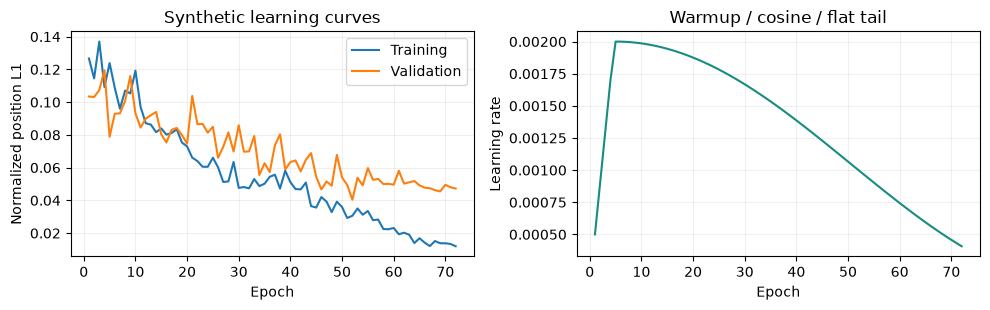

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
epochs = [row["epoch"] for row in history]
axes[0].plot(epochs, [row["train_loss"] for row in history], label="Training")
axes[0].plot(epochs, [row["validation_loss"] for row in history], label="Validation")
axes[0].set(xlabel="Epoch", ylabel="Normalized position L1", title="Synthetic learning curves")
axes[0].legend()
axes[1].plot(epochs, [row["lr"] for row in history], color="#178d81")
axes[1].set(xlabel="Epoch", ylabel="Learning rate", title="Warmup / cosine / flat tail")
for axis in axes:
    axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)

## 5. Inspect the trained notebook model in 3D

This view uses the notebook's newly trained weights, not the API checkpoint.
Camera orientation is fixed synthetic input and is not predicted. If the optional
PyTorch3D point-cloud/transform components are installed, the same verified
PyTorch3D→Plotly adapter as the web demo is used; otherwise the backend is explicitly
reported as Plotly. See `docs/pytorch3d.md` for installation.

The interactive figure also exports to `generated/notebook_demo/scene.html` with
its JavaScript embedded. Open that file if your notebook viewer cannot display
Plotly output. GitHub may show only static notebook previews.

The room point cloud and reference trajectory are synthetic display context. They are separate from the notebook's generated observation recipes and are not model input. The displayed test prediction comes from this training run.

In [11]:
item = datasets["test"][0]
batch = next(iter(DataLoader([item], batch_size=1)))
with torch.inference_mode():
    output = model(**{key: batch[key] for key in INPUT_KEYS})
position = (output["p0"][0] * SCALE).tolist()
truth = (item["p0"] * SCALE).tolist()
candidates_m = (item["candidate_positions"] * SCALE).tolist()
weights = output["candidate_weights"][0].tolist()
quaternion = [0.5, 0.5, 0.5, 0.5]  # provided camera +Z points along world +X
result = {
    "position": position,
    "ground_truth": truth,
    "prediction": {
        "position": position,
        "quaternion": quaternion,
        "orientation_source": "provided synthetic camera pose; not predicted",
    },
    "truth": {"position": truth, "quaternion": quaternion},
    "candidate_positions": candidates_m,
    "candidate_weights": weights,
    "candidate_refined_positions": (output["candidate_refined_positions"][0] * SCALE).tolist(),
    "candidates": [
        {
            "id": spec["candidates"][int(index)]["id"],
            "position": point,
            "quaternion": quaternion,
            "score": sum(weight) / 3,
        }
        for index, point, weight in zip(item["candidate_indices"], candidates_m, weights)
    ],
}
try:
    from pytorch3d.structures import Pointclouds  # noqa: F401
    from pytorch3d.transforms import quaternion_to_matrix  # noqa: F401

    backend = "pytorch3d"
except (ImportError, OSError):
    backend = "plotly"
scene_figure = build_figure(load_scene(), result, color_mode="feature", backend=backend)
scene_figure.write_html(OUTPUT / "scene.html", include_plotlyjs=True, auto_open=False)
print(f"Visualization backend: {backend}; exported generated/notebook_demo/scene.html")
scene_figure.show(renderer="plotly_mimetype")

Visualization backend: pytorch3d; exported generated/notebook_demo/scene.html


## 6. Reproducibility checks

Check finite held-out metrics, training improvement, checkpoint round-trip,
padding-mask invariance and expected visualization traces. All metrics refer to
the disclosed synthetic distribution. Regenerate the small input JSON with
`python scripts/generate_notebook_data.py`; rerun all cells to train again.

In [12]:
assert math.isfinite(test_metrics["mean_error_m"])
assert best_validation["loss"] < initial_validation["loss"], "Training should improve toy validation loss"
reloaded = SCTTransformer(hidden_dim=spec["hidden_dim"], desc_dim=spec["desc_dim"])
reloaded.load_state_dict(torch.load(OUTPUT / "best_weights.pt", map_location="cpu", weights_only=True))
reloaded.eval()
with torch.inference_mode():
    restored = reloaded(**{key: batch[key] for key in INPUT_KEYS})
torch.testing.assert_close(output["p0"], restored["p0"])
masked_batch = next(
    iter(
        DataLoader(
            [
                next(
                    datasets["test"][i]
                    for i in range(len(datasets["test"]))
                    if not datasets["test"][i]["mask"].all()
                )
            ],
            batch_size=1,
        )
    )
)
changed = {**masked_batch, "feats": {key: value.clone() for key, value in masked_batch["feats"].items()}}
for key, value in changed["feats"].items():
    value[~masked_batch["mask"]] = 999
with torch.inference_mode():
    normal = model(**{key: masked_batch[key] for key in INPUT_KEYS})["p0"]
    padded = model(**{key: changed[key] for key in INPUT_KEYS})["p0"]
torch.testing.assert_close(normal, padded, atol=1e-5, rtol=1e-5)
assert {"Predicted position", "Synthetic ground truth"}.issubset({trace.name for trace in scene_figure.data})
assert (OUTPUT / "scene.html").is_file()
print(
    "PASS: independent splits, finite test metrics, toy learning, safe checkpoint round-trip, masks and 3D output."
)
print(f"Held-out synthetic mean error: {test_metrics['mean_error_m']:.3f} m (not a real-world benchmark).")

PASS: independent splits, finite test metrics, toy learning, safe checkpoint round-trip, masks and 3D output.
Held-out synthetic mean error: 0.316 m (not a real-world benchmark).
